<a href="https://colab.research.google.com/github/xKABIRAJ/gz/blob/main/Polynomial_regre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline


In [16]:
X = 6 * np.random.rand(200, 1) -3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1)

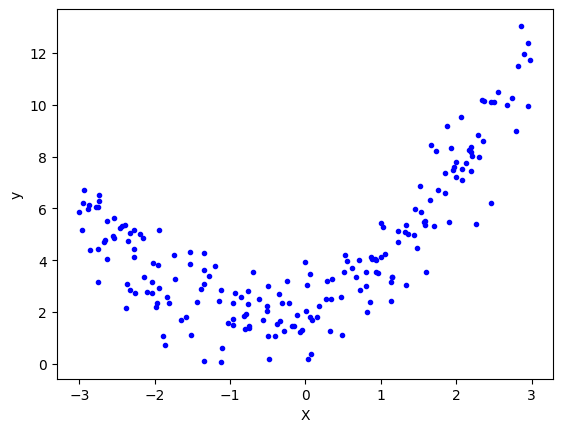

In [17]:
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state =2 )

In [19]:
lr = LinearRegression()

In [20]:
lr.fit(X_train,y_train)

LinearRegression()

In [21]:
y_pred = lr.predict(X_test)
r2_score (y_test,y_pred)

0.15267991524345936

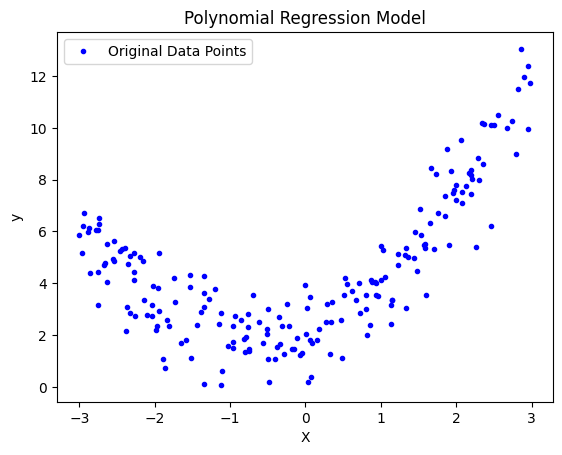

In [22]:
import matplotlib.pyplot as plt


plt.plot(X,y,"b.", label = 'Original Data Points')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression Model")
plt.legend()
plt.show()

In [23]:
# Applying polynomial linear Regression # degree 2

poly = PolynomialFeatures(degree = 2, include_bias = True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)


In [24]:
print(X_train[0])
print(X_train_trans[0])

[0.6202202]
[1.         0.6202202  0.38467309]


In [25]:
# Include_bias_ parameter


In [26]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [27]:
y_pred = lr.predict(X_test_trans)

In [28]:
r2_score(y_test,y_pred)

0.8504767179612346

In [29]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.98511038 0.75786827]]
[2.22965018]


In [30]:
X_new = np.linspace (-3, 3, 200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

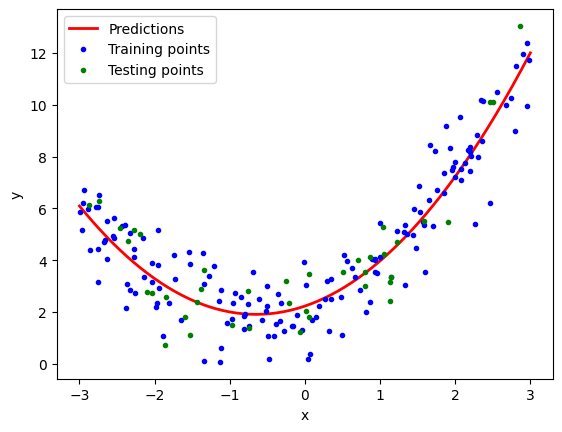

In [31]:
plt.plot(X_new,y_new,"r",linewidth = 2, label = "Predictions")
plt.plot(X_train, y_train , "b.", label = "Training points")
plt.plot(X_test,y_test,"g.",label = "Testing points")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [34]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

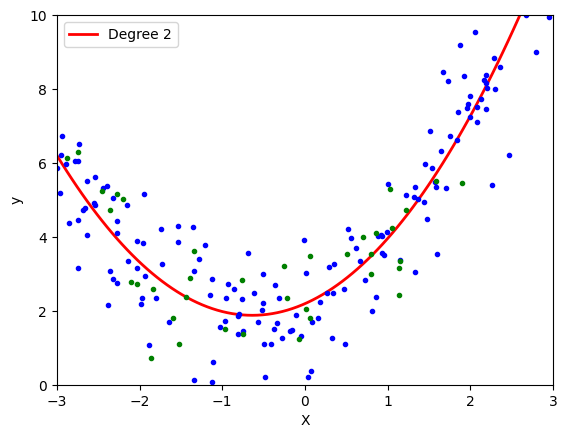

In [37]:
polynomial_regression(2)

In [38]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [39]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [41]:

lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [42]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [43]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)